In [0]:
# =============================================================
# SAP Finance Insights Pipeline - Orchestrator
# =============================================================
# Simulates a CI/CD pipeline by chaining the 3 use case notebooks.
# In production, this would be a Databricks Job with 3 tasks.

from datetime import datetime
start = datetime.now()
print(f"Pipeline started: {start}")

print("\n=== Step 1: SQL AI Query Insights ===")
insights_df = spark.sql("""
WITH monthly_totals AS (
  SELECT DATE_TRUNC('MONTH', PostingDate) AS month,
         CompanyCode,
         ROUND(SUM(AmountInGlobalCurrency), 2) AS monthly_total
  FROM bdc_share_cash_flow.cashflow.cashflow
  WHERE PostingDate >= '2025-01-01'
  GROUP BY month, CompanyCode
),
baseline AS (
  SELECT CompanyCode,
         ROUND(AVG(monthly_total), 2) AS avg_monthly,
         ROUND(STDDEV(monthly_total), 2) AS stddev_monthly
  FROM monthly_totals
  GROUP BY CompanyCode
)
SELECT m.month, m.CompanyCode, m.monthly_total, b.avg_monthly,
       ROUND((m.monthly_total - b.avg_monthly) / NULLIF(b.stddev_monthly, 0), 2) AS z_score,
       CASE 
         WHEN ABS((m.monthly_total - b.avg_monthly) / NULLIF(b.stddev_monthly, 0)) >= 2 THEN 'ANOMALY'
         WHEN ABS((m.monthly_total - b.avg_monthly) / NULLIF(b.stddev_monthly, 0)) >= 1 THEN 'WATCH'
         ELSE 'NORMAL'
       END AS classification
FROM monthly_totals m
JOIN baseline b ON m.CompanyCode = b.CompanyCode
ORDER BY m.month DESC
LIMIT 10
""")
display(insights_df)
print(f"Step 1 completed at: {datetime.now()}")

Pipeline started: 2026-09-09 01:27:02.768997

=== Step 1: SQL AI Query Insights ===


month,CompanyCode,monthly_total,avg_monthly,z_score,classification
2026-09-01T00:00:00.000Z,1710,-7509.91,44311199.35,-1.19,WATCH
2026-08-01T00:00:00.000Z,1710,-26104.76,44311199.35,-1.19,WATCH
2026-07-01T00:00:00.000Z,1710,-26152.03,44311199.35,-1.19,WATCH
2026-06-01T00:00:00.000Z,1710,-26808.14,44311199.35,-1.19,WATCH
2026-05-01T00:00:00.000Z,1710,841132.49,44311199.35,-1.17,WATCH
2026-04-01T00:00:00.000Z,1010,9729813.00,31296290.50,-0.61,NORMAL
2026-04-01T00:00:00.000Z,1710,31686904.76,44311199.35,-0.34,NORMAL
2026-03-01T00:00:00.000Z,1010,95770187.00,31296290.50,1.82,WATCH
2026-03-01T00:00:00.000Z,1710,112680723.91,44311199.35,1.84,WATCH
2026-02-01T00:00:00.000Z,1010,82733021.00,31296290.50,1.46,WATCH


Step 1 completed at: 2026-09-09 01:27:11.637665


In [0]:
print("\n=== Step 2: Visualizations ===")


=== Step 2: Visualizations ===


In [0]:
from datetime import datetime
print(f"Step 2 completed at: {datetime.now()}")

Step 2 completed at: 2026-09-09 01:27:14.632087


In [0]:
print("\n=== Step 3: Multi-Agent Analysis ===")


=== Step 3: Multi-Agent Analysis ===


# LangGraph Multi-Agent Supervisor for Delta Shares

A supervisor agent routes tasks to three specialized sub-agents — Schema Explorer, Query Agent, and Summary Agent — each equipped with Spark SQL tools to discover, query, and profile Delta Share data.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
databricks-agents 1.9.1 requires mlflow-skinny<4.0.0,>=3.6.0, but you have mlflow-skinny 2.22.5 which is incompatible.
grpcio-status 1.67.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
langchain-openai 1.1.6 requires langchain-core<2.0.0,>=1.2.2, but you have langchain-core 0.3.86 which is incompatible.
opentelemetry-proto 1.39.1 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


/home/spark-9a4481ad-87f4-4af7-91a8-b5/.ipykernel/75/command-5880283424066350-3590648709:13: LangChainDeprecationWarning: Use databricks_langchain.ChatDatabricks
  llm = ChatDatabricks(endpoint="databricks-meta-llama-3-3-70b-instruct")


✓ Multi-agent supervisor graph compiled successfully


/home/spark-9a4481ad-87f4-4af7-91a8-b5/.ipykernel/75/command-5880283424066352-1246129302:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  schema_explorer = create_react_agent(
/home/spark-9a4481ad-87f4-4af7-91a8-b5/.ipykernel/75/command-5880283424066352-1246129302:13: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  query_agent = create_react_agent(
/home/spark-9a4481ad-87f4-4af7-91a8-b5/.ipykernel/75/command-5880283424066352-1246129302:23: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  summary_

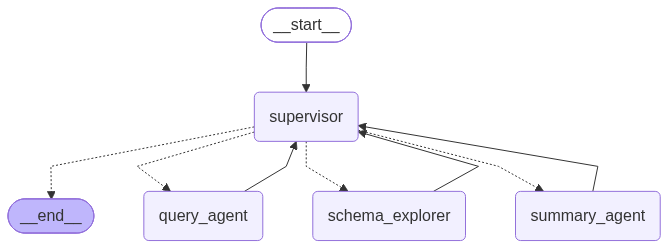

{"ts": "2026-09-09 01:27:43.565", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjkzODM3NzYxNDE2MDE1MxABIAEyJDAxYTA4M2JiLTI0YTYtNzEwZS1hNzQyLWI2YTQ3YWZiOTliNDokMDEyMTQyNzYtYTA0Yy0zNThhLWI0YWEtN2E1MDQwMGRmZWYwSgsI++WC1QYQgM/3FVABWAFgAWjTwLK6z8qpBA==.", "context": {}}
{"ts": "2026-09-09 01:27:43.565", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjkzODM3NzYxNDE2MDE1MxABIAEyJDAxYTA4M2JiLTI0YTYtNzEwZS1hNzQyLWI2YTQ3YWZiOTliNDokMDEyMTQyNzYtYTA0Yy0zNThhLWI0YWEtN2E1MDQwMGRmZWYwSgsI++WC1QYQgM/3FVABWAFgAWjTwLK6z8qpBA==.", "context": {}}
{"ts": "2026-09-09 01:27:43.565", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjkzODM3NzYxNDE2MDE1MxABIAEyJDAxYTA4M2JiLTI0YTYtNzEwZS1hNzQyLWI2YTQ3YWZiOTliNDokMDEyMTQyNzYtYTA0Yy0zNThhLWI0YWEtN2E1MDQwMGRmZWYw

[HUMAN] For the table bdc_share_cash_flow.cashflow.cashflow, first get its schema, then query the top 5 company codes by total AmountInGlobalCurrency, and finally profile the table to show row counts and null rates.
————————————————————————————————————————————————————————————
[AI] 
————————————————————————————————————————————————————————————
[TOOL] {"table": "bdc_share_cash_flow.cashflow.cashflow", "columns": [{"name": "CashFlowID", "type": "string"}, {"name": "CshFlwValdtyStrtDteTmeVal", "type": "decimal(21,7)"}, {"name": "CompanyCode", "type": "string"}, {"name": "TransactionDate", "type": "date"}, {"name": "PostingDate", "type": "date"}, {"name": "TransactionCurrency", "type": "string"}, {"name": "AmountInTransactionCurrency", "type": "decimal(34,4)"}, {"name": "CompanyCodeCurrency", "type": "string"}, {"name": "AmountInCompanyCodeCurre
————————————————————————————————————————————————————————————
[AI] 
————————————————————————————————————————————————————————————
[TOOL] {"rows": [{"C

[HUMAN] List all available catalogs and describe what tables each one contains.
————————————————————————————————————————————————————————————
[AI] 
————————————————————————————————————————————————————————————
[TOOL] {"catalogs": ["bdc_share_cash_flow", "bdc_share_costcenter", "bdc_share_customer", "bdc_share_glaccount", "bdc_share_journal_entry", "bdc_share_supplier", "bdc_share_vendorperformance", "cashflow_data_product", "company_code_data_product", "companycode_share", "product_share", "samples", "system", "workspace"]}
————————————————————————————————————————————————————————————
[AI] 
————————————————————————————————————————————————————————————
[TOOL] {"catalog": "bdc_share_cash_flow", "schemas": [{"schema": "cashflow", "tables": ["cashflow", "cashflowforecast"]}, {"schema": "information_schema", "tables": ["abac_policy_definitions", "catalog_privileges", "catalog_tags", "catalogs", "check_constraints", "column_masks", "column_tags", "columns", "constraint_column_usage", "constraint

In [0]:
%run "./Drafts/LangGraph Multi-Agent Supervisor Delta Shares"

In [0]:
from datetime import datetime
print(f"Step 3 completed at: {datetime.now()}")

end = datetime.now()
try:
    print(f"\n{'='*60}\nPipeline completed in: {end - start}\n{'='*60}")
except NameError:
    print(f"\n{'='*60}\nPipeline completed at: {end}\n(timing unavailable \u2014 Python restarted during %run)\n{'='*60}")

Step 3 completed at: 2026-09-09 01:30:00.329359

Pipeline completed at: 2026-09-09 01:30:00.329520
(timing unavailable — Python restarted during %run)
